### Lab 04: DECISION TREE CLASSIFIER

### **Student Information**

- **Name:** Abdullah Farooq
- **Roll_no:** 24F-AI-050

#### Lab Tasks:

- Task 1: Load Dataset
  * Use a dataset such as Iris dataset (from sklearn) or load any CSV file.
- Task 2: Exploratory Data Analysis (EDA)
  * Display dataset information, shape, and statistical summary.
  * Plot distributions of features (histograms / pairplot).
  * Visualize correlations
- Task 3: Data Preprocessing
  * Split dataset into training and testing sets (e.g., 70% train, 30% test).
- Task 4: Build Decision Tree Classifier
  * Train the model using DecisionTreeClassifier.
- Task 5: Model Evaluation
  * Make predictions on the test data.
  * Evaluate using:
    - Accuracy Score
    - Confusion Matrix
    - Classification Report
- Task 6: Experimentation
  * Change parameters (criterion = "gini" vs "entropy", max_depth, min_samples_split).
  * Compare results and observe overfitting vs underfitting.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set standard plotting style
sns.set_theme(style="whitegrid")

In [4]:
plt.rcParams['figure.figsize'] = [4.4, 3.1]

plt.rcParams['figure.autolayout'] = True

In [2]:
# Task 1: Load Dataset

# Use the Iris dataset from sklearn
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target 

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



Generating Pairplot...


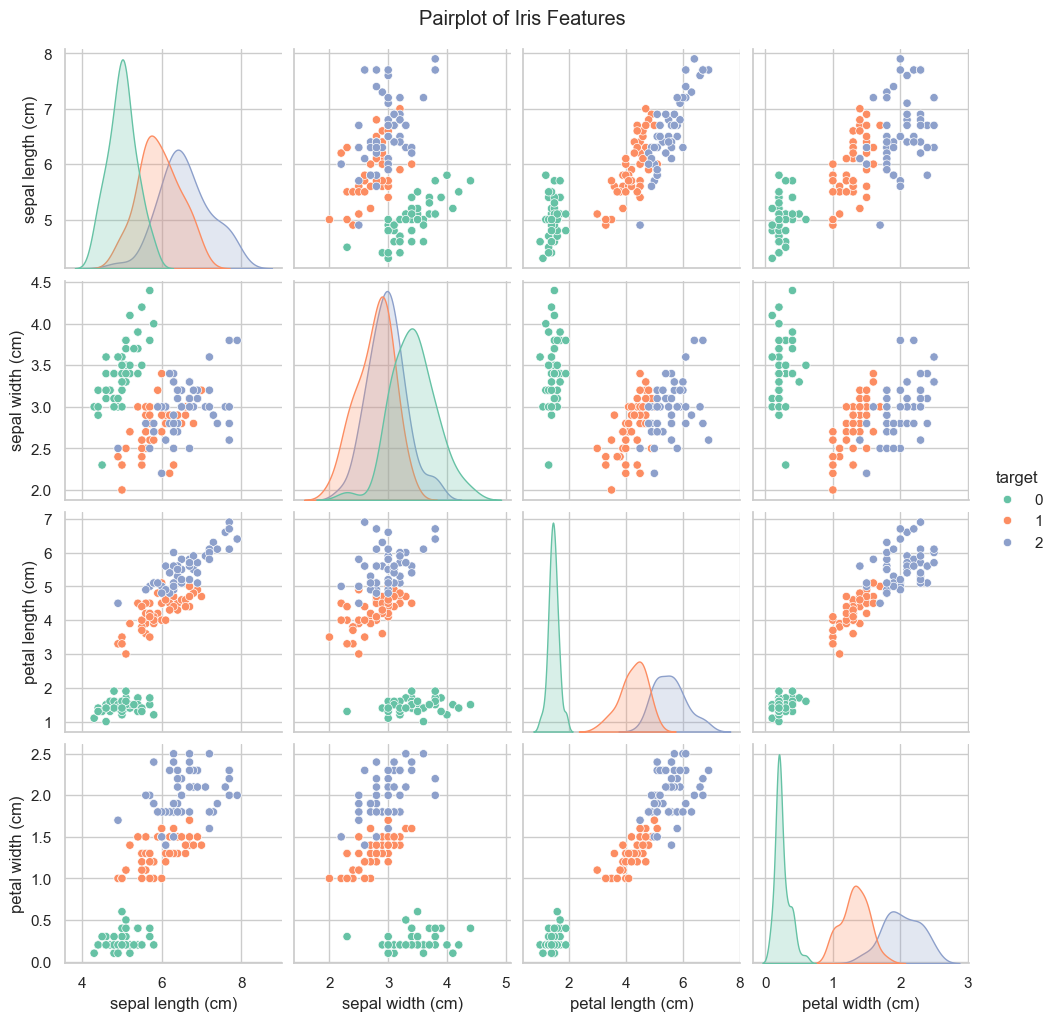


Generating Correlation Heatmap...


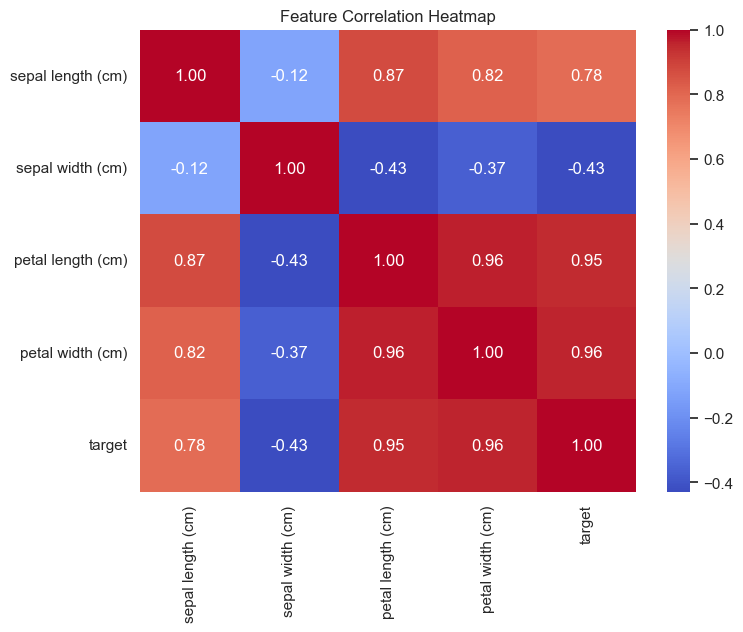

In [3]:
# Task 2: Exploratory Data Analysis (EDA)

# Display dataset information
df.info()

# Display dataset shape
print(f"Shape: {df.shape}")

# Display statistical summary
display(df.describe())

# Plot distributions of features (pairplot)
print("\nGenerating Pairplot...")
sns.pairplot(df, hue="target", palette="Set2")
plt.suptitle("Pairplot of Iris Features", y=1.02)
plt.show()

# Visualize correlations
print("\nGenerating Correlation Heatmap...")
plt.figure(figsize=(8, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

In [5]:
# Task 3: Data Preprocessing

X = df.drop(columns=['target'])
y = df['target']

# Split dataset into training and testing sets (70% train, 30% test)[cite: 21]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [6]:
# Task 4: Build Decision Tree Classifier
# ==========================================
# Train the model using DecisionTreeClassifier (Default parameters: Gini)
clf_default = DecisionTreeClassifier(random_state=42)
clf_default.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

--- Default Model Evaluation ---
Accuracy Score: 1.0000



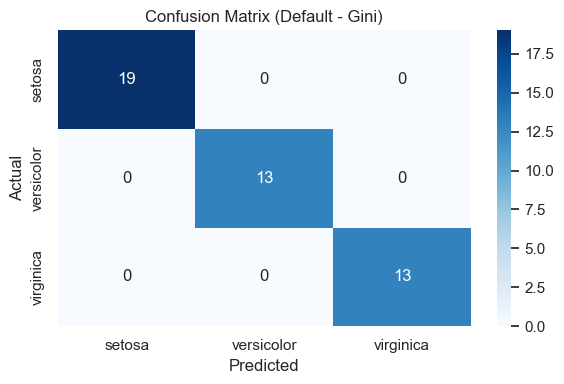

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [7]:
# Task 5: Model Evaluation

# Make predictions on the test data
y_pred = clf_default.predict(X_test)

print("--- Default Model Evaluation ---")
# Accuracy Score
acc_default = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {acc_default:.4f}\n")

# Confusion Matrix[cite: 22]
cm_default = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_default, annot=True, cmap="Blues", fmt='d', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("Confusion Matrix (Default - Gini)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

In [8]:
# Task 6: Experimentation[cite: 22]

print("\n--- Experimenting with Parameters ---")
# Change parameters (criterion = "entropy", max_depth, min_samples_split)
clf_experiment = DecisionTreeClassifier(
    criterion="entropy", 
    max_depth=3, 
    min_samples_split=4, 
    random_state=42
)

# Train and predict with the new model
clf_experiment.fit(X_train, y_train)
y_pred_exp = clf_experiment.predict(X_test)

# Compare results
acc_exp = accuracy_score(y_test, y_pred_exp)
print(f"Experiment Model Accuracy (Entropy, max_depth=3, min_samples_split=4): {acc_exp:.4f}")
print(f"Default Model Accuracy (Gini, unbounded depth): {acc_default:.4f}")

print("\nObservation regarding Overfitting vs Underfitting[cite: 22]:")
print("By limiting the `max_depth` (pre-pruning), we constrain the tree's complexity. If the unconstrained default model fits noise perfectly but performs worse on test data, it is overfitting. Pruning parameters like max_depth and min_samples_split help improve generalization and prevent overfitting.")


--- Experimenting with Parameters ---
Experiment Model Accuracy (Entropy, max_depth=3, min_samples_split=4): 0.9778
Default Model Accuracy (Gini, unbounded depth): 1.0000

Observation regarding Overfitting vs Underfitting[cite: 22]:
By limiting the `max_depth` (pre-pruning), we constrain the tree's complexity. If the unconstrained default model fits noise perfectly but performs worse on test data, it is overfitting. Pruning parameters like max_depth and min_samples_split help improve generalization and prevent overfitting.
